# TÓPICOS DE MATEMÁTICA PARA SISTEMAS AUTÓNOMOS

## TRABALHO LETIVO — ENTREGA 1

**Visualização de trajetórias e referenciais de vários robôs**  
ISEP · 2026 · Grupo 07

---

**Nota 1:** Todos os elementos do grupo são responsáveis por esta entrega.  
**Nota 2:** Todos os elementos do grupo tomaram conhecimento das regras estabelecidas para o funcionamento da UC no [Moodle do ISEP](https://moodle.isep.ipp.pt).

---

## GRUPO 07

| Número de aluno | Nome |
|---|---|
| 1221309 | Henrique Correia |
| 1231177 | Pedro Ribeiro |
| 1231216 | Francisco Liquito |

<a id="conteudo"></a>
# Conteúdo

1. [Identificação dos objetivos e estruturação do problema](#sec1)
2. [Justificação da relevância das bibliotecas Python selecionadas](#sec2)
3. [Metodologia proposta para o desenvolvimento do projeto](#sec3)

Nesta primeira entrega explicamos o que pretendemos desenvolver, as bibliotecas que escolhemos e os passos que vamos seguir. Incluímos também uma análise inicial dos ficheiros fornecidos.

<a id="sec1"></a>
## 1. Identificação dos objetivos e estruturação do problema

[De volta para o conteúdo](#conteudo)

Pretendemos desenvolver uma aplicação web em Python/Dash para visualizar os percursos de vários robôs a partir dos registos de uma missão. A aplicação deverá permitir acompanhar a posição e a orientação de cada robô ao longo do tempo.

De acordo com o enunciado, vamos trabalhar nas seguintes funcionalidades:

- **Vista global:** mostrar todos os robôs num referencial comum, com os seus percursos e posições no instante escolhido. Cada robô terá uma cor diferente.
- **Vista local:** escolher um robô e mostrar o seu percurso, a sua orientação e os robôs próximos em relação a ele.
- **Reprodução da missão:** acrescentar uma barra de tempo, botões Play/Pause e a possibilidade de escolher um instante.
- **Configuração em YAML:** guardar num ficheiro os parâmetros usados pela aplicação.
- **Ficheiros de saída:** permitir guardar os registos resultantes e a configuração utilizada.

Para realizar estas tarefas, precisamos de ler os dados, alinhar os registos pelo tempo e converter as coordenadas. A parte matemática principal será passar das coordenadas de um referencial para outro.

### Dados fornecidos

O ZIP contém três ficheiros de dados, `robot1_s1.csv`, `robot4_s1.csv` e `robot7_s1.csv`, e um README que explica os campos. Os registos são de missões realizadas na Aguçadoura, no âmbito de atividades do INESC TEC, e a sua utilização está limitada à UC.

Para o trabalho, os campos mais importantes são:

- **Tempo:** `header.stamp.secs` e `header.stamp.nsecs` indicam o instante original de cada mensagem. O campo `Time` refere-se ao registo no ficheiro.
- **Posição:** segundo o README, `pose.pose.position.x` é a latitude, `.y` é a longitude e `.z` é a altitude. As duas primeiras estão em graus e a altitude está em metros.
- **Orientação:** os campos `pose.pose.orientation.x`, `.y`, `.z` e `.w` formam um quaternion, isto é, quatro valores que representam a orientação do robô no espaço.
- **Referenciais:** `header.frame_id` e `child_frame_id` identificam os referenciais usados nos registos.

Os ficheiros também incluem velocidades e informação sobre a incerteza das estimativas. A nossa primeira abordagem vai centrar-se no tempo, na posição e na orientação.

O README fornece uma posição de referência: latitude **41.45201666666667°**, longitude **−8.81322222222222°** e altitude **55.44791126176966 m**. Pretendemos usá-la como origem comum. Como a latitude e a longitude estão em graus, teremos de as converter antes de calcular distâncias em metros.

### Análise inicial dos dados

O código seguinte lê os três CSV e apresenta o número de registos, a duração e algumas verificações básicas. O gráfico mostra em que períodos existem dados de cada robô.

Para executar as células, colocar `TL2026.zip` na mesma pasta do notebook e usar Python 3 com NumPy, pandas e Matplotlib. Se necessário, instalar estas bibliotecas com `python -m pip install numpy pandas matplotlib`. Os resultados já estão guardados no notebook.

In [1]:
from pathlib import Path
from zipfile import ZipFile
import platform

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

CAMINHO_ZIP = Path("TL2026.zip")  # Ajustar apenas se o ZIP estiver noutra pasta.
FICHEIROS = {
    "Robô 1": "robot1_s1.csv",
    "Robô 4": "robot4_s1.csv",
    "Robô 7": "robot7_s1.csv",
}
COL_POS = [f"pose.pose.position.{eixo}" for eixo in "xyz"]
COL_QUAT = [f"pose.pose.orientation.{eixo}" for eixo in "xyzw"]
COL_TEMPO = ["header.stamp.secs", "header.stamp.nsecs"]

if not CAMINHO_ZIP.is_file():
    raise FileNotFoundError("Colocar TL2026.zip junto do notebook ou ajustar CAMINHO_ZIP.")

dados = {}
with ZipFile(CAMINHO_ZIP) as arquivo:
    for robo, nome in FICHEIROS.items():
        with arquivo.open(nome) as ficheiro:
            dados[robo] = pd.read_csv(ficheiro)

print(f"Ficheiros lidos: {len(dados)} | Total de registos: {sum(len(df) for df in dados.values())}")
print(f"Ambiente: Python {platform.python_version()} | NumPy {np.__version__} | "
      f"pandas {pd.__version__} | Matplotlib {matplotlib.__version__}")

Ficheiros lidos: 3 | Total de registos: 30152
Ambiente: Python 3.12.14 | NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8


In [2]:
instantes_ns = {}
linhas_resumo = []
linhas_verificacao = []

for robo, df in dados.items():
    # Conservar o timestamp em inteiros; converter apenas as diferenças para segundos.
    t_ns = (df["header.stamp.secs"].to_numpy(dtype=np.int64) * 1_000_000_000
            + df["header.stamp.nsecs"].to_numpy(dtype=np.int64))
    instantes_ns[robo] = t_ns
    intervalos_s = np.diff(t_ns) / 1e9
    q = df[COL_QUAT].to_numpy(dtype=float)
    colunas_principais = df[COL_TEMPO + COL_POS + COL_QUAT].to_numpy(dtype=float)

    linhas_resumo.append({
        "Robô": robo,
        "Registos": len(df),
        "Colunas": df.shape[1],
        "Duração (min)": (t_ns.max() - t_ns.min()) / 60e9,
        "Δt mediano (s)": np.median(intervalos_s),
        "frame_id": ", ".join(df["header.frame_id"].dropna().unique()),
    })
    linhas_verificacao.append({
        "Robô": robo,
        "Valores em falta": int(df.isna().sum().sum()),
        "Tempos por ordem": "Sim" if np.all(intervalos_s > 0) else "Não",
        "Não finitos (t, p, q)": int(np.sum(~np.isfinite(colunas_principais))),
        # Verificar se o comprimento (norma) dos quaterniões difere de 1 em menos de 0,000001.
        "Normas próximas de 1": "Sim" if np.all(
            np.abs(np.linalg.norm(q, axis=1) - 1) < 1e-6) else "Não",
    })

resumo = pd.DataFrame(linhas_resumo).set_index("Robô")
verificacao = pd.DataFrame(linhas_verificacao).set_index("Robô")
display(resumo.round({"Duração (min)": 2, "Δt mediano (s)": 3}))
display(verificacao)

inicio_comum_ns = max(t.min() for t in instantes_ns.values())
fim_comum_ns = min(t.max() for t in instantes_ns.values())
duracao_comum_min = max(0, fim_comum_ns - inicio_comum_ns) / 60e9
print(f"Duração do intervalo temporal comum aos três ficheiros: {duracao_comum_min:.2f} min.")

,Registos,Colunas,Duração (min),Δt mediano (s),frame_id
Robô,,,,,
Robô 1,9537,21,84.83,0.52,world_ned
Robô 4,5615,21,49.92,0.52,world_ned
Robô 7,15000,21,133.54,0.52,WGS84


,Valores em falta,Tempos por ordem,"Não finitos (t, p, q)",Normas próximas de 1
Robô,,,,
Robô 1,0,Sim,0,Sim
Robô 4,0,Sim,0,Sim
Robô 7,0,Sim,0,Sim


Duração do intervalo temporal comum aos três ficheiros: 39.94 min.


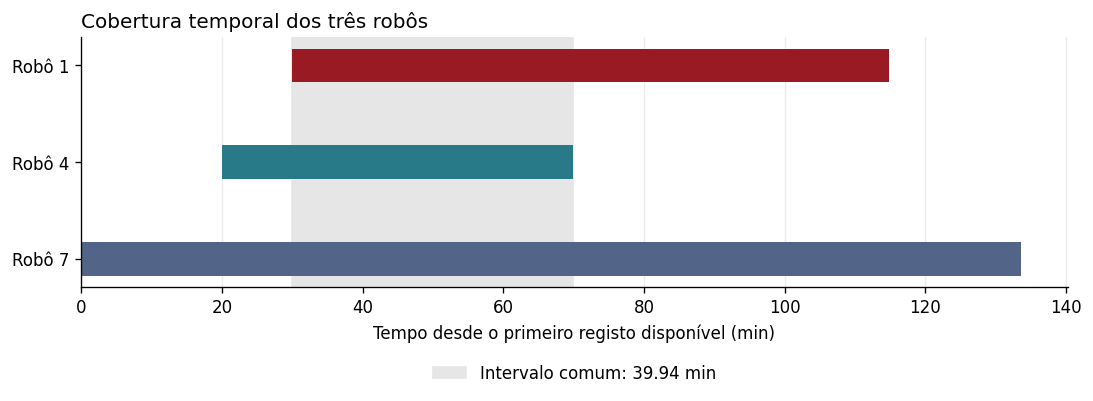

In [3]:
# Cobertura temporal dos ficheiros, medida a partir do primeiro registo disponível.
origem_ns = min(t.min() for t in instantes_ns.values())
cores = ["#9A1A24", "#287A89", "#526487"]
fig, ax = plt.subplots(figsize=(9, 3.2), dpi=120, layout="constrained")

if fim_comum_ns > inicio_comum_ns:
    ax.axvspan((inicio_comum_ns - origem_ns) / 60e9,
               (fim_comum_ns - origem_ns) / 60e9,
               color="#E6E6E6", label=f"Intervalo comum: {duracao_comum_min:.2f} min")

for (robo, t_ns), cor in zip(instantes_ns.items(), cores):
    inicio_min = (t_ns.min() - origem_ns) / 60e9
    duracao_min = (t_ns.max() - t_ns.min()) / 60e9
    ax.barh(robo, duracao_min, left=inicio_min, height=0.35, color=cor)

ax.invert_yaxis()
ax.set_xlabel("Tempo desde o primeiro registo disponível (min)")
ax.set_title("Cobertura temporal dos três robôs", loc="left")
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), frameon=False)
plt.show()

Lemos **30 152 registos**, distribuídos por três ficheiros com 21 colunas. Não encontrámos valores em falta nem tempos repetidos ou fora de ordem. Também não encontrámos valores indefinidos ou infinitos nas colunas de tempo, posição e orientação verificadas. As normas dos quaterniões estão próximas de 1.

Os ficheiros começam e terminam em momentos diferentes. Há cerca de **39,94 minutos** em que os três têm dados, e o intervalo mediano entre registos é de aproximadamente **0,52 s**. Por isso, teremos de usar os tempos de cada registo para comparar os robôs, em vez de juntar linhas com o mesmo número.

Nos robôs 1 e 4, o campo `header.frame_id` tem o valor `world_ned`; no robô 7 aparece `WGS84`. Precisamos de esclarecer esta diferença antes de interpretar as orientações. Para as posições, seguimos a indicação do README: latitude, longitude e altitude.

<a id="sec2"></a>
## 2. Justificação da relevância das bibliotecas Python selecionadas

[De volta para o conteúdo](#conteudo)

Escolhemos as bibliotecas tendo em conta as tarefas do projeto e os exemplos das aulas. O exemplo de referenciais já usa NumPy, Plotly e SciPy para representar um ponto com posição e orientação, pelo que será uma base para esta parte do trabalho.

| Biblioteca | Para que a vamos usar |
|---|---|
| [pandas](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) | Ler os CSV e organizar os registos em tabelas, facilitando a escolha das colunas e a verificação dos dados. |
| [NumPy](https://numpy.org/doc/stable/) | Trabalhar com vetores e matrizes nos cálculos de posições e mudanças de referencial. Também é usada na análise inicial. |
| [SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.transform.Rotation.from_quat.html) | Obter matrizes de rotação a partir dos quaterniões, usando `Rotation`, e aplicar essas rotações às posições. |
| [Plotly](https://plotly.com/python/3d-scatter-plots/) | Desenhar gráficos 3D interativos com as trajetórias, os robôs e os eixos dos referenciais. |
| [Dash](https://dash.plotly.com/basic-callbacks) | Construir a interface em Python e ligar os controlos de tempo e seleção de robô aos gráficos. |
| [PyYAML](https://pyyaml.org/wiki/PyYAMLDocumentation) | Ler e guardar a configuração em YAML, para alterar parâmetros sem modificar o código. |
| [Matplotlib](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.barh.html) | Criar o gráfico simples usado nesta análise inicial. Para os gráficos da aplicação, usaremos Plotly. |

Usamos ainda `pathlib` e `zipfile`, que fazem parte do Python, para localizar o ZIP e ler os ficheiros que contém.

<a id="sec3"></a>
## 3. Metodologia proposta para o desenvolvimento do projeto

[De volta para o conteúdo](#conteudo)

Vamos desenvolver o projeto por etapas, começando pelos dados e pelos cálculos antes de construir a interface completa.

1. **Ler e verificar os dados.** Confirmar as colunas, unidades e tempos dos três robôs. Identificar registos incompletos ou inválidos e manter os ficheiros originais.
2. **Organizar os registos pelo tempo.** Usar o instante original das mensagens e começar pelo período em que existem dados dos três robôs. Para cada instante escolhido, procurar o registo mais próximo de cada um.
3. **Converter as coordenadas.** Passar da latitude, longitude e altitude para um referencial comum em metros. Depois, calcular as posições em relação ao robô selecionado.
4. **Construir as duas vistas.** Mostrar os percursos, posições e orientações na vista global e na vista local. Usar uma cor por robô e identificar os eixos e as unidades.
5. **Acrescentar os controlos e ficheiros.** Integrar a barra de tempo, Play/Pause, seleção do robô, leitura da configuração YAML e gravação dos resultados.
6. **Testar e rever.** Confirmar os cálculos e o funcionamento da aplicação. Preparar a explicação do trabalho para a segunda entrega, prevista para a semana 8.

Vamos separar a leitura dos ficheiros, os cálculos e os gráficos em funções, para facilitar a organização e a correção de erros. Os três elementos participarão na revisão do trabalho.

### Tempo e reprodução

Propomos começar com um passo de **0,5 s** na reprodução. Para cada instante, aceitaremos o registo mais próximo se a diferença de tempo não ultrapassar **0,3 s**. Estes valores são uma escolha inicial e poderão ser ajustados nos testes.

Quando um robô não tiver dados suficientemente próximos, ou estiver fora do seu período de registo, será mostrado como indisponível. A barra de tempo e os botões usarão o mesmo instante nas duas vistas.

### Coordenadas e referenciais

Seguindo os referenciais apresentados no enunciado, pretendemos converter as posições para ECEF, com origem no centro da Terra, e depois para NED, com os eixos Norte, Este e Baixo. O NED ficará fixo na posição de referência fornecida e será comum aos três robôs. Antes desta conversão, precisamos de confirmar qual é a referência usada para medir a altitude.

Na vista local, o robô escolhido fica na origem. Para representar outro robô em relação a ele, primeiro subtraímos a posição do robô escolhido e depois aplicamos a rotação inversa da sua orientação:

$$p_{\mathrm{local}} = R^T(p-p_0).$$

Nesta expressão, $p$ é a posição do ponto e $p_0$ a posição do robô escolhido, ambas no referencial comum. A matriz $R$ transforma os eixos do robô para esse referencial; a sua transposta faz a rotação inversa.

Vamos usar os quaterniões na ordem `(x, y, z, w)` para obter as matrizes de rotação. Antes disso, teremos de confirmar os eixos e o sentido das rotações usados nos ficheiros. O percurso mostrado na vista local será todo expresso no referencial do robô no instante selecionado. Uma distância máxima, definida na configuração, permitirá escolher os robôs considerados próximos.

### Configuração e resultados

O YAML incluirá os ficheiros a ler, os nomes e cores dos robôs, a origem e as convenções das coordenadas, o passo de tempo, a tolerância temporal e a distância de proximidade.

Para a saída, propomos guardar um CSV com o tempo, o robô, a posição calculada e o referencial usado, juntamente com o YAML da configuração. Se o referencial for o de um robô, esse robô também será identificado no CSV. Vamos confirmar com o professor se este conteúdo corresponde ao pretendido.

### Verificação do funcionamento

Para verificar os cálculos, vamos começar com posições simples e rotações conhecidas, como 90°. O robô escolhido deve ficar na origem do seu referencial, as distâncias entre pontos devem manter-se e a transformação inversa deve recuperar as posições iniciais.

Na aplicação, vamos comparar as posições mostradas com os registos usados, testar o início e o fim da missão, a pausa e os períodos sem dados de um robô. Também vamos voltar a carregar a configuração guardada e comparar os valores exportados com os calculados.

Antes de fechar a implementação, precisamos de esclarecer com o professor as diferenças entre `world_ned` e `WGS84`, a referência da altitude e se os robôs usam uma base de tempo comum. Vamos também confirmar o papel de AER e do OpenSeaMap, que aparecem nos slides, e o formato esperado para os ficheiros de saída.

### Fontes consultadas

- Pedro Barbosa Guedes, *TL- TOMSA - 2026.pdf*, em particular as funcionalidades do slide 2 e os requisitos de entrega do slide 7.
- *TOMSA2026_TL_readme.pdf*, incluído em `TL2026.zip`.
- Notebook *exemplo - referenciais* e tutoriais de NumPy e Matplotlib disponibilizados na UC.
- Documentação oficial das bibliotecas, indicada nos links da secção 2.
- Documentação do PROJ sobre a [conversão para coordenadas locais](https://proj.org/en/stable/operations/conversions/topocentric.html), usada como apoio ao planeamento das conversões.

Documentação online consultada em 1 de outubro de 2026.